In [25]:
import asyncio
from sipyco.sync_struct import Subscriber

# Create an asyncio Event to wait for updates
dataset_updated = asyncio.Event()


async def connect_subscriber(name, db: dict, port=None, server=None):
    port = 3250 if port is None else port
    server = "137.222.69.28" if server is None else server

    def _create(data):
        db.update(data)
        return db

    def _update(mod):
        # Signal that an update has occurred
        dataset_updated.set()

    subscriber = Subscriber(name, _create, _update, None)
    try:
        await subscriber.connect(
            server,
            port,
        )
    except asyncio.TimeoutError:
        print(f"Failed to connect to Sub: {name} at {server}:{port}")
        return
    print(f"Connected to Sub: {name} at {server}:{port}")
    return subscriber

**DO NOT add extra code to this lower cell.**

Due to jupyter notebook async weirdness it won't actually await the return before running subsequent code

In [26]:
# Run the connection in an asyncio event loop
db = {}
sub = await connect_subscriber("datasets", db)
await dataset_updated.wait()
# await sub.close()
print("Received dataset update!")

Connected to Sub: datasets at 137.222.69.28:3250
Received dataset update!


In [27]:
# get the RID of the latest dataset
keys = list(db.keys())
# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")

Selected RID: 24727 from ['24727']


Task was destroyed but it is pending!
task: <Task pending name='Task-6' coro=<Subscriber._receive_cr() running at /home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/sipyco/sync_struct.py:149> wait_for=<Future pending cb=[Task.task_wakeup()]>>
Task was destroyed but it is pending!
task: <Task pending name='Task-10' coro=<Subscriber._receive_cr() running at /home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/sipyco/sync_struct.py:149> wait_for=<Future pending cb=[Task.task_wakeup()]>>


Num points: 76
Atom number: 0.70e8 +- 0.36e8


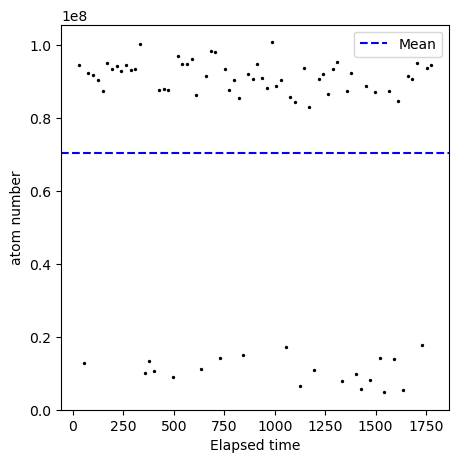

In [28]:
import matplotlib.pyplot as plt
import json
import numpy as np

axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig,ax = plt.subplots(1, num_axes, figsize=(5*num_axes, 5))
if num_axes == 1:
    ax = [ax]  # Ensure ax is always a list for consistency
for i in range(num_axes):
    ax[i].scatter(
        db[f"ndscan.rid_{RID}.points.axis_{i}"][1],
        db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
        s=2,
        color='k',
    )

    ax[i].set_xlabel(axes[i]["param"]["description"])
    ax[i].set_ylabel("atom number")
    ax[i].set_ylim(bottom=0)

numbers= db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]
print(f"Num points: {len(numbers)}")

ax[0].axhline(np.mean(numbers), color='b', linestyle='--', label='Mean')
ax[0].legend()

print(f"Atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8")

Text(0, 0.5, 'Number of atoms')

Task was destroyed but it is pending!
task: <Task pending name='Task-6' coro=<Subscriber._receive_cr() running at /home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/sipyco/sync_struct.py:149> wait_for=<Future pending cb=[Task.task_wakeup()]>>


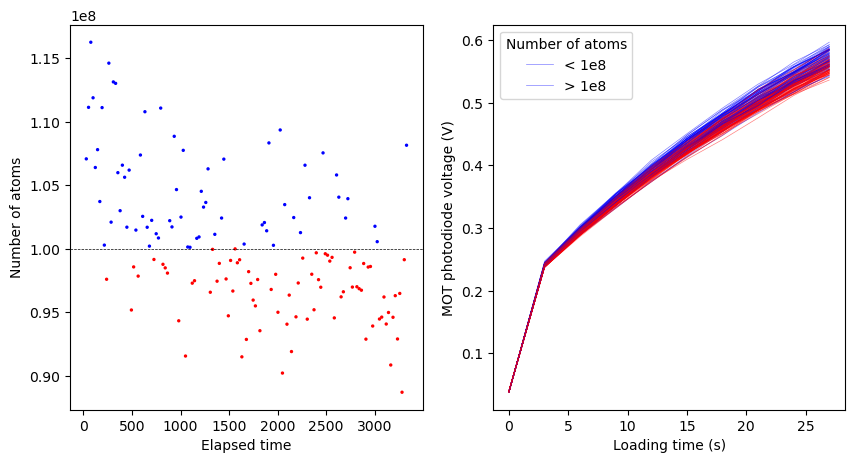

In [35]:
import numpy as np
import matplotlib.pyplot as plt

loading = np.asarray(db[f"ndscan.rid_{RID}.points.channel_mot_voltages"][1])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i in range(len(numbers)):
    color = 'r' if numbers[i] < 1e8 else 'b'
    ax[1].plot(np.arange(0,30,3), loading[i], color=color, alpha=0.5, linewidth=0.5)

ax[1].legend(title="Number of atoms", labels=["< 1e8", "> 1e8"])
ax[1].set_xlabel("Loading time (s)")
ax[1].set_ylabel("MOT photodiode voltage (V)")

ax[0].scatter(
    db[f"ndscan.rid_{RID}.points.axis_0"][1],
    db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
    s=2,
    color=['r' if n < 1e8 else 'b' for n in numbers])
ax[0].axhline(1e8, color='k', linestyle='--', linewidth=0.5)
ax[0].set_xlabel(axes[0]["param"]["description"])
ax[0].set_ylabel("Number of atoms")